Step 1 — Import Libraries

In [2]:
# Import required libraries

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras import layers, models

# YOLO
try:
    from ultralytics import YOLO
    print("All libraries imported successfully!")
except ImportError:
    print("Warning: 'ultralytics' package is not installed. Please run Step 2 first!")

Step 2 — Install Required Libraries

In [ ]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 6.5 MB/s eta 0:00:00


Step 3 — Load the YOLO Model

In [ ]:
from ultralytics import YOLO

# Load the pretrained YOLO model
model = YOLO("yolo11n.pt")

print("YOLO model loaded successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
YOLO model loaded successfully!


Step 4 — Download a Test Image

In [ ]:
# Download a sample image for object detection

from ultralytics.utils.downloads import download

image_url = "https://ultralytics.com/images/bus.jpg"

download(image_url, dir="/content", exist_ok=True)

image_path = "/content/bus.jpg"

print("Image downloaded successfully!")
print("Image path:", image_path)

Image downloaded successfully!
Image path: /content/bus.jpg


Step 5 — Display the Original Image

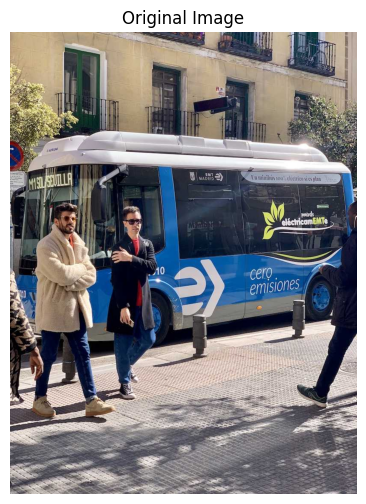

In [ ]:
# Read and display the original image

image = cv2.imread(image_path)

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Original Image")
plt.show()

Step 6 — Perform Object Detection Using YOLO

In [ ]:
# Perform object detection

results = model(image_path)

print("Object detection completed successfully!")


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 463.1ms
Speed: 31.5ms preprocess, 463.1ms inference, 38.8ms postprocess per image at shape (1, 3, 640, 480)
Object detection completed successfully!


Step 7 — Display Object Detection Results

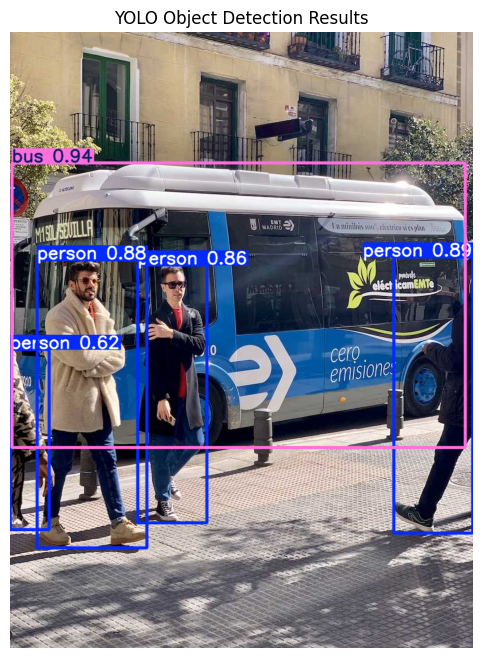

In [ ]:
# Display YOLO detection results

result_image = results[0].plot()

# Convert BGR to RGB for Matplotlib
result_image_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(result_image_rgb)
plt.axis("off")
plt.title("YOLO Object Detection Results")
plt.show()

Step 8 — Display Detected Objects and Confidence Scores

In [ ]:
# Display detected objects and confidence scores

for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = model.names[class_id]

        print(f"Object: {class_name} | Confidence: {confidence:.2f}")

Object: bus | Confidence: 0.94
Object: person | Confidence: 0.89
Object: person | Confidence: 0.88
Object: person | Confidence: 0.86
Object: person | Confidence: 0.62


Step 9 — Count the Detected Objects

In [ ]:
# Count detected objects

detected_objects = []

for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        detected_objects.append(class_name)

print("Total objects detected:", len(detected_objects))
print("Detected objects:", detected_objects)

Total objects detected: 5
Detected objects: ['bus', 'person', 'person', 'person', 'person']


Step 10 — Evaluate YOLO Using mAP

In [ ]:
# Evaluate YOLO model using the COCO8 validation dataset

metrics = model.val(data="coco8.yaml")

print("YOLO evaluation completed!")

Ultralytics 8.4.170 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

WARNING ⚠️ Dataset 'coco8.yaml' images not found, missing path '/content/datasets/coco8/images/val'
Unzipping /content/datasets/coco8.zip to /content/datasets/coco8...: 100% ━━━━━━━━━━━━ 25/25 623.5files/s 0.0s
Dataset download success ✅ (0.5s), saved to /content/datasets

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 909.6±443.8 MB/s, size: 54.0 KB)
val: Scanning /content/datasets/coco8/labels/val... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 318.5it/s 0.0s
val: New cache created: /content/datasets/coco8/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.8s/it 2.8s
                   all          4         17       0.57       0.85      0.846       0.63
                person          3         10      0.557        0.6    

In [ ]:
# Display mAP results

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

mAP50: 0.8461790945924886
mAP50-95: 0.6304297600978563


Step 11 — Prepare for Image Segmentation

In [ ]:
# Download Oxford-IIIT Pet segmentation dataset

import tensorflow as tf

dataset_url = "http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
annotations_url = "http://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz"

print("Downloading image dataset...")
tf.keras.utils.get_file(
    "images.tar.gz",
    dataset_url,
    extract=True,
    cache_dir="/content",
    cache_subdir="pets"
)

print("Downloading annotation dataset...")
tf.keras.utils.get_file(
    "annotations.tar.gz",
    annotations_url,
    extract=True,
    cache_dir="/content",
    cache_subdir="pets"
)

print("Dataset downloaded successfully!")

791918971/791918971 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
19173078/19173078 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset downloaded successfully!


Step 12 — Check the Dataset Folders

In [ ]:
# Check downloaded dataset folders

import os

print("Pet dataset folder:")
print(os.listdir("/content/pets"))

print("\nImages folder exists:",
      os.path.exists("/content/pets/images"))

print("Annotations folder exists:",
      os.path.exists("/content/pets/annotations"))

Pet dataset folder:
['annotations.tar.gz', 'images_extracted', 'images.tar.gz', 'annotations_extracted']

Images folder exists: False
Annotations folder exists: False


Step 13 — Load Image and Segmentation Mask

In [ ]:
# Load one sample image and its segmentation mask

import os
import cv2
import matplotlib.pyplot as plt

image_dir = "/content/pets/images_extracted/images"
mask_dir = "/content/pets/annotations_extracted/trimaps"

# Get the first available image
image_files = [
    f for f in os.listdir(image_dir)
    if f.endswith(".jpg")
]

image_name = image_files[0]
image_path = os.path.join(image_dir, image_name)

# Corresponding mask has the same name but .png extension
mask_name = image_name.replace(".jpg", ".png")
mask_path = os.path.join(mask_dir, mask_name)

print("Image:", image_name)
print("Image path:", image_path)
print("Mask path:", mask_path)
print("Mask exists:", os.path.exists(mask_path))

Image: Sphynx_139.jpg
Image path: /content/pets/images_extracted/images/Sphynx_139.jpg
Mask path: /content/pets/annotations_extracted/trimaps/Sphynx_139.png
Mask exists: False


Step 14 — Load a Sample Image and Mask

In [ ]:
# Get image files

image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith(".jpg")
]

# Select the first image
image_name = image_files[0]

image_path = os.path.join(image_dir, image_name)

# Create corresponding mask path
mask_name = image_name.rsplit(".", 1)[0] + ".png"
mask_path = os.path.join(mask_dir, mask_name)

print("Image:", image_name)
print("Image path:", image_path)
print("Mask path:", mask_path)
print("Mask exists:", os.path.exists(mask_path))

Image: Sphynx_139.jpg
Image path: /content/pets/images_extracted/images/Sphynx_139.jpg
Mask path: /content/pets/annotations_extracted/trimaps/Sphynx_139.png
Mask exists: False


Step 15 — Display Original Image and Ground-Truth Mask

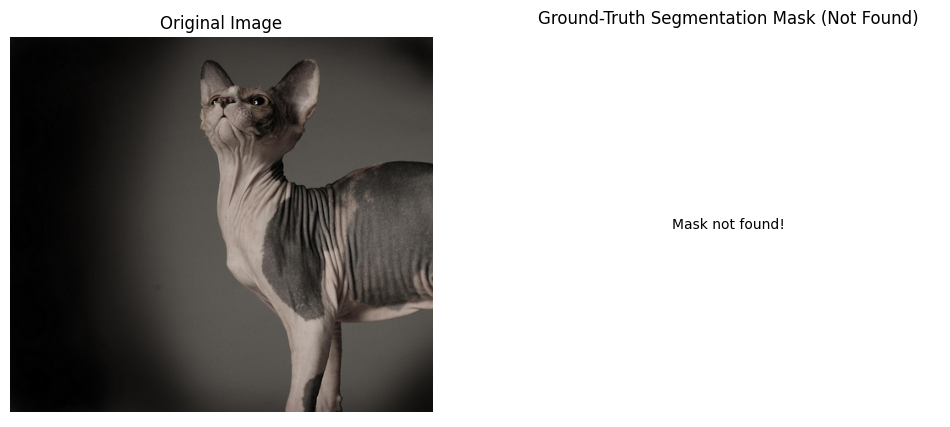

In [ ]:
# Load image and segmentation mask

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

# Display both
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
if mask is not None:
    plt.imshow(mask, cmap="gray")
    plt.title("Ground-Truth Segmentation Mask")
else:
    plt.text(0.5, 0.5, "Mask not found!", horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
    plt.title("Ground-Truth Segmentation Mask (Not Found)")
plt.axis("off")

plt.show()

Step 16 — Prepare Images and Masks for U-Net

In [ ]:
# Prepare images and segmentation masks

IMG_SIZE = 128
NUM_IMAGES = 500

X = []
Y = []

# Use images that have corresponding masks
valid_files = []

image_dir = "/content/pets/images_extracted/images"
mask_dir = "/content/pets/annotations_extracted/annotations/trimaps" # Corrected path

print(f"Checking for masks in: {mask_dir}")
try:
    actual_mask_filenames = os.listdir(mask_dir)
    print(f"Found {len(actual_mask_filenames)} files in mask directory. First 5: {actual_mask_filenames[:5]}")
except FileNotFoundError:
    print(f"Mask directory {mask_dir} not found!")
    actual_mask_filenames = []

# Create a set of base names for quick lookup
actual_mask_basenames = {f.rsplit('.', 1)[0] for f in actual_mask_filenames if f.endswith('.png')}
print(f"Number of unique mask basenames: {len(actual_mask_basenames)}")

for filename in image_files:
    mask_basename = filename.rsplit(".", 1)[0]
    # Check if the mask's basename exists in our set of actual mask basenames
    if mask_basename in actual_mask_basenames:
        mask_file = os.path.join(mask_dir, mask_basename + ".png")
        valid_files.append(filename)
    # else:
    #     print(f"DEBUG: Mask not found for {filename} (basename {mask_basename})")


# Limit dataset size
valid_files = valid_files[:NUM_IMAGES]

print(f"Number of valid image files with corresponding masks found: {len(valid_files)}")

for filename in valid_files:
    # Image path
    img_path = os.path.join(image_dir, filename)

    # Mask path
    mask_filename = filename.rsplit(".", 1)[0] + ".png"
    msk_path = os.path.join(mask_dir, mask_filename)

    # Read image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Normalize image
    img = img.astype(np.float32) / 255.0

    # Read mask
    msk = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)
    msk = cv2.resize(
        msk,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_NEAREST
    )

    # Convert trimap to binary mask
    # Pet = 1, background = 0
    # The original mask values are 1 (pet), 2 (background), 3 (border).
    # We want to create a binary mask where pet is 1 and everything else is 0.
    msk = (msk == 1).astype(np.float32)

    # Add channel dimension
    msk = np.expand_dims(msk, axis=-1)

    X.append(img)
    Y.append(msk)

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.float32)

print("Dataset preparation completed!")
print("Images shape:", X.shape)
print("Masks shape:", Y.shape)


Checking for masks in: /content/pets/annotations_extracted/annotations/trimaps
Found 14780 files in mask directory. First 5: ['Persian_172.png', 'saint_bernard_190.png', '._japanese_chin_155.png', 'Ragdoll_87.png', '._saint_bernard_144.png']
Number of unique mask basenames: 14780
Number of valid image files with corresponding masks found: 500
Dataset preparation completed!
Images shape: (500, 128, 128, 3)
Masks shape: (500, 128, 128, 1)


Step 17 — Split Dataset into Training and Testing Sets

In [ ]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("Training images:", X_train.shape)
print("Training masks:", Y_train.shape)

print("Testing images:", X_test.shape)
print("Testing masks:", Y_test.shape)

Training images: (400, 128, 128, 3)
Training masks: (400, 128, 128, 1)
Testing images: (100, 128, 128, 3)
Testing masks: (100, 128, 128, 1)


Step 18 — Build the U-Net Model

In [ ]:
# Build U-Net model

def build_unet(input_shape=(128, 128, 3)):

    inputs = layers.Input(input_shape)

    # -------------------------
    # Encoder
    # -------------------------

    conv1 = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    conv1 = layers.Conv2D(32, 3, activation="relu", padding="same")(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = layers.Conv2D(64, 3, activation="relu", padding="same")(pool1)
    conv2 = layers.Conv2D(64, 3, activation="relu", padding="same")(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = layers.Conv2D(128, 3, activation="relu", padding="same")(pool2)
    conv3 = layers.Conv2D(128, 3, activation="relu", padding="same")(conv3)
    pool3 = layers.MaxPooling2D(pool_size=(2, 2))(conv3)

    # -------------------------
    # Bottleneck
    # -------------------------

    bottleneck = layers.Conv2D(
        256, 3, activation="relu", padding="same"
    )(pool3)

    bottleneck = layers.Conv2D(
        256, 3, activation="relu", padding="same"
    )(bottleneck)

    # -------------------------
    # Decoder
    # -------------------------

    up3 = layers.UpSampling2D(size=(2, 2))(bottleneck)
    up3 = layers.Concatenate()([up3, conv3])

    conv4 = layers.Conv2D(
        128, 3, activation="relu", padding="same"
    )(up3)

    conv4 = layers.Conv2D(
        128, 3, activation="relu", padding="same"
    )(conv4)

    up2 = layers.UpSampling2D(size=(2, 2))(conv4)
    up2 = layers.Concatenate()([up2, conv2])

    conv5 = layers.Conv2D(
        64, 3, activation="relu", padding="same"
    )(up2)

    conv5 = layers.Conv2D(
        64, 3, activation="relu", padding="same"
    )(conv5)

    up1 = layers.UpSampling2D(size=(2, 2))(conv5)
    up1 = layers.Concatenate()([up1, conv1])

    conv6 = layers.Conv2D(
        32, 3, activation="relu", padding="same"
    )(up1)

    conv6 = layers.Conv2D(
        32, 3, activation="relu", padding="same"
    )(conv6)

    # Output segmentation mask
    outputs = layers.Conv2D(
        1, 1, activation="sigmoid"
    )(conv6)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model


unet = build_unet()

print("U-Net model created successfully!")

U-Net model created successfully!


Step 19 — Display U-Net Model Summary

In [ ]:
# Display U-Net architecture

unet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 64, 64,    │          0 │ conv2d_9[0][0]  

 Total params: 1,946,881 (7.43 MB)

 Trainable params: 1,946,881 (7.43 MB)

 Non-trainable params: 0 (0.00 B)

Step 20 — Compile the U-Net Model

In [ ]:
# Compile the U-Net model

unet.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("U-Net model compiled successfully!")

U-Net model compiled successfully!


Step 21 — Train the U-Net Model

In [ ]:
# Train the U-Net model

history = unet.fit(
    X_train,
    Y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=16,
    verbose=1
)

print("U-Net training completed successfully!")

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 175s 9s/step - accuracy: 0.7028 - loss: 0.6165 - val_accuracy: 0.7409 - val_loss: 0.5198
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 206s 9s/step - accuracy: 0.7029 - loss: 0.5559 - val_accuracy: 0.7409 - val_loss: 0.4781
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 168s 8s/step - accuracy: 0.7029 - loss: 0.5075 - val_accuracy: 0.7409 - val_loss: 0.4544
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 190s 8s/step - accuracy: 0.7029 - loss: 0.4981 - val_accuracy: 0.7409 - val_loss: 0.4360
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 146s 7s/step - accuracy: 0.7618 - loss: 0.4707 - val_accuracy: 0.8139 - val_loss: 0.4269
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 149s 7s/step - accuracy: 0.7879 - loss: 0.4614 - val_accuracy: 0.8107 - val_loss: 0.4145
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 151s 8s/step - accuracy: 0.7853 - loss: 0.4534 - val_accuracy: 0.7958 - val_loss: 0.4178
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 147s 7s/step - accuracy: 0.7872 - loss: 0.4535 - val_accuracy: 0.8154 - v

Step 22 — Plot Training and Validation Performance

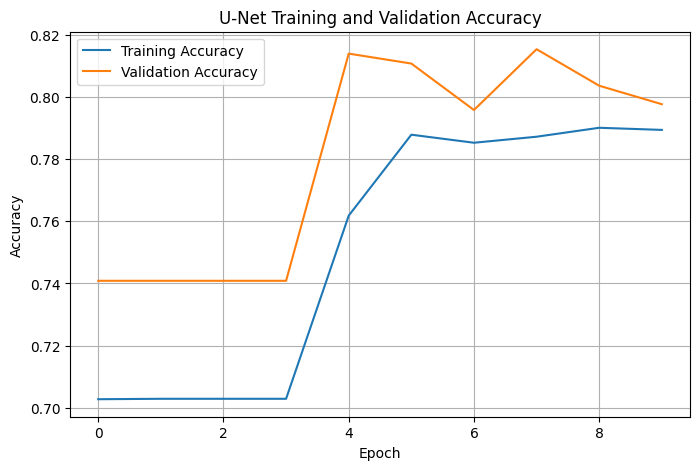

In [ ]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("U-Net Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

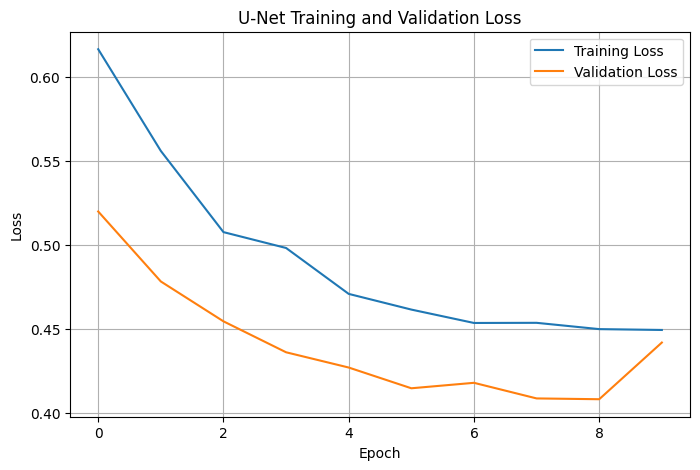

In [ ]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("U-Net Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

Step 23 — Generate Segmentation Predictions

In [ ]:
# Generate segmentation predictions

predictions = unet.predict(X_test)

print("Segmentation predictions generated successfully!")
print("Prediction shape:", predictions.shape)

4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step
Segmentation predictions generated successfully!
Prediction shape: (100, 128, 128, 1)


In [ ]:
# Convert predicted probabilities into binary masks

predicted_masks = (predictions > 0.5).astype(np.float32)

print("Binary segmentation masks created!")
print("Mask shape:", predicted_masks.shape)

Binary segmentation masks created!
Mask shape: (100, 128, 128, 1)


Step 24 — Visualize Segmentation Results

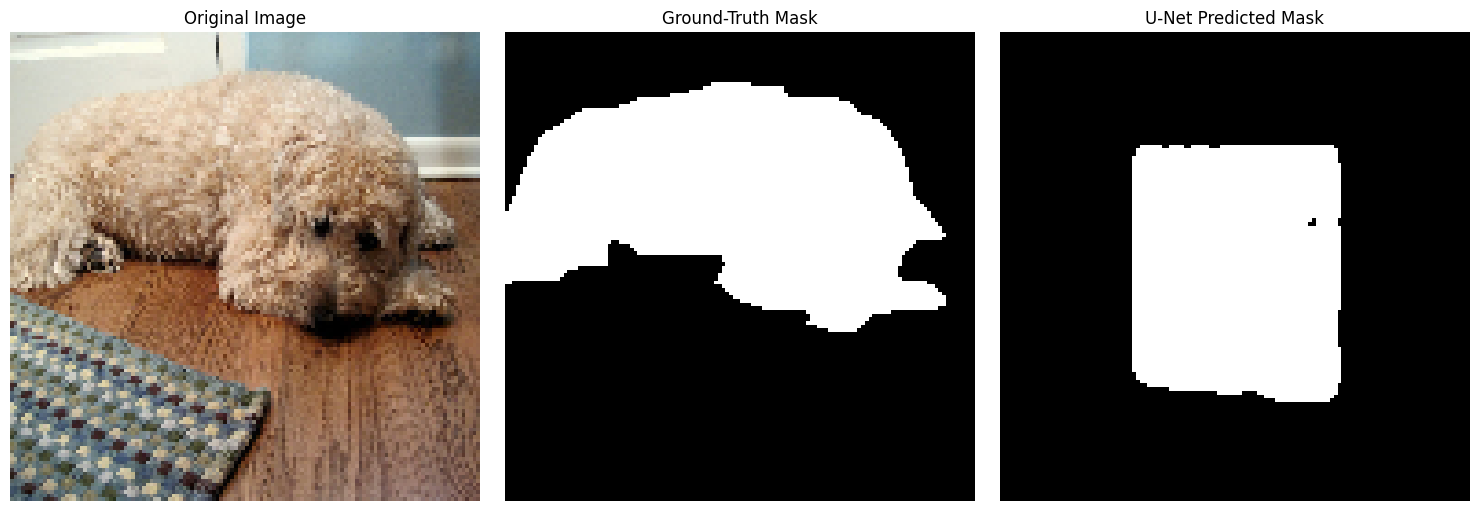

In [ ]:
# Visualize U-Net segmentation results

sample_index = 0

plt.figure(figsize=(15, 5))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(X_test[sample_index])
plt.title("Original Image")
plt.axis("off")

# Ground-truth mask
plt.subplot(1, 3, 2)
plt.imshow(Y_test[sample_index].squeeze(), cmap="gray")
plt.title("Ground-Truth Mask")
plt.axis("off")

# Predicted mask
plt.subplot(1, 3, 3)
plt.imshow(predicted_masks[sample_index].squeeze(), cmap="gray")
plt.title("U-Net Predicted Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

Step 25 — Calculate IoU (Intersection over Union)

In [ ]:
# Calculate Intersection over Union (IoU)

def calculate_iou(y_true, y_pred):
    y_true = y_true.astype(bool)
    y_pred = y_pred.astype(bool)

    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()

    if union == 0:
        return 1.0

    return intersection / union


iou_scores = []

for i in range(len(Y_test)):
    iou = calculate_iou(
        Y_test[i].squeeze(),
        predicted_masks[i].squeeze()
    )
    iou_scores.append(iou)

mean_iou = np.mean(iou_scores)

print(f"Mean IoU: {mean_iou:.4f}")

Mean IoU: 0.4174


Step 26 — Calculate Dice Score

In [ ]:
# Calculate Dice Score

def calculate_dice(y_true, y_pred):
    y_true = y_true.astype(bool)
    y_pred = y_pred.astype(bool)

    intersection = np.logical_and(y_true, y_pred).sum()

    dice = (2 * intersection) / (
        y_true.sum() + y_pred.sum() + 1e-7
    )

    return dice


dice_scores = []

for i in range(len(Y_test)):
    dice = calculate_dice(
        Y_test[i].squeeze(),
        predicted_masks[i].squeeze()
    )
    dice_scores.append(dice)

mean_dice = np.mean(dice_scores)

print(f"Mean Dice Score: {mean_dice:.4f}")

Mean Dice Score: 0.5757


Step 27 — Create Performance Evaluation Summary

In [ ]:
# Create performance evaluation summary

print("=" * 50)
print("PERFORMANCE EVALUATION SUMMARY")
print("=" * 50)

print(f"YOLO mAP50       : {metrics.box.map50:.4f}")
print(f"YOLO mAP50-95    : {metrics.box.map:.4f}")
print(f"U-Net Mean IoU   : {mean_iou:.4f}")
print(f"U-Net Mean Dice  : {mean_dice:.4f}")

print("=" * 50)

PERFORMANCE EVALUATION SUMMARY
YOLO mAP50       : 0.8462
YOLO mAP50-95    : 0.6304
U-Net Mean IoU   : 0.4174
U-Net Mean Dice  : 0.5757


Step 28 — Create a Comparison Table

In [ ]:
# Compare Object Detection and Image Segmentation

comparison = {
    "Aspect": [
        "Model",
        "Task",
        "Output",
        "Evaluation Metric",
        "Main Purpose"
    ],

    "Object Detection": [
        "YOLO",
        "Object Detection",
        "Bounding Boxes",
        "mAP",
        "Locate and classify objects"
    ],

    "Image Segmentation": [
        "U-Net",
        "Semantic Segmentation",
        "Pixel-level Masks",
        "IoU and Dice Score",
        "Classify pixels in the image"
    ]
}

import pandas as pd

comparison_df = pd.DataFrame(comparison)

display(comparison_df)

,Aspect,Object Detection,Image Segmentation
0,Model,YOLO,U-Net
1,Task,Object Detection,Semantic Segmentation
2,Output,Bounding Boxes,Pixel-level Masks
3,Evaluation Metric,mAP,IoU and Dice Score
4,Main Purpose,Locate and classify objects,Classify pixels in the image


Step 29 — Add Observations

## Observations

1. YOLO successfully detected objects in the input images and localized them using bounding boxes.

2. The detected objects were displayed with their class labels and confidence scores.

3. The YOLO model was evaluated using mAP50 and mAP50-95.

4. U-Net was implemented for semantic image segmentation using the Oxford-IIIT Pet dataset.

5. The U-Net model generated pixel-level segmentation masks for the test images.

6. The segmentation performance was evaluated using Mean IoU and Mean Dice Score.

7. IoU measures the overlap between the predicted segmentation and the ground-truth mask.

8. Dice Score measures the similarity between the predicted mask and the actual mask.

9. Object detection and image segmentation solve different computer vision problems. Object detection focuses on locating and classifying objects, whereas segmentation provides pixel-level information.

10. The visual results show the difference between bounding-box-based object detection and pixel-level image segmentation.

Step 30 — Add Applications

## Applications

### Object Detection using YOLO

- Autonomous vehicles
- Surveillance systems
- Traffic monitoring
- Retail product detection
- Industrial inspection
- Real-time video analysis

### Image Segmentation using U-Net

- Medical image analysis
- Satellite image analysis
- Autonomous driving
- Background and foreground separation
- Agricultural image analysis
- Object boundary detection

Step 31 — Add Conclusion

## Conclusion

In this task, object detection and image segmentation were implemented using YOLO and U-Net respectively. YOLO was used to detect and localize objects using bounding boxes, while U-Net was used to perform pixel-level semantic segmentation.

The object detection model was evaluated using mAP, while the segmentation model was evaluated using IoU and Dice Score. Prediction visualizations were also generated to compare the model outputs with the original images and ground-truth masks.

The experiment demonstrated that object detection and image segmentation provide different types of information and are useful for different computer vision applications.

Step 33 — Save the Trained U-Net Model

In [ ]:
# Save the trained U-Net model

model_save_path = "/content/unet_segmentation_model.keras"

unet.save(model_save_path)

print("U-Net model saved successfully!")
print("Saved at:", model_save_path)

U-Net model saved successfully!
Saved at: /content/unet_segmentation_model.keras


Step 34 — Save YOLO Detection Results

In [ ]:
# Save YOLO detection visualization

output_path = "/content/yolo_detection_result.jpg"

cv2.imwrite(
    output_path,
    cv2.cvtColor(result_image_rgb, cv2.COLOR_RGB2BGR)
)

print("YOLO result saved successfully!")
print("Saved at:", output_path)

YOLO result saved successfully!
Saved at: /content/yolo_detection_result.jpg


Step 35 — Save U-Net Segmentation Visualization

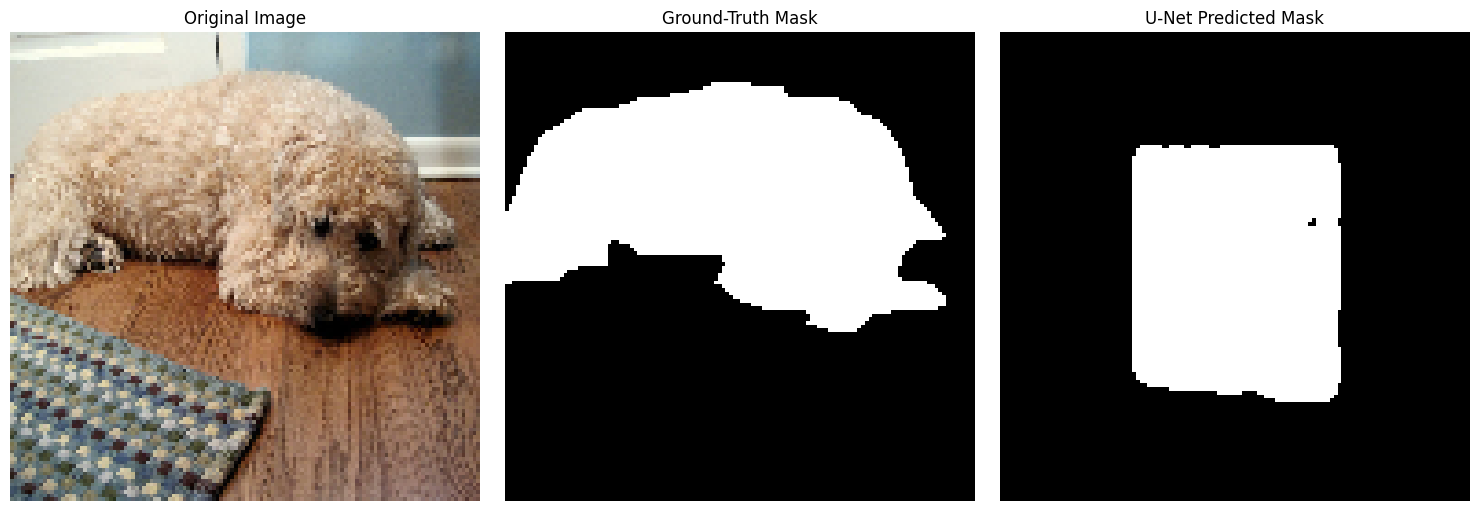

Segmentation result saved successfully!
Saved at: /content/unet_segmentation_result.png


In [ ]:
# Save U-Net segmentation visualization

sample_index = 0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(X_test[sample_index])
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(Y_test[sample_index].squeeze(), cmap="gray")
axes[1].set_title("Ground-Truth Mask")
axes[1].axis("off")

axes[2].imshow(predicted_masks[sample_index].squeeze(), cmap="gray")
axes[2].set_title("U-Net Predicted Mask")
axes[2].axis("off")

plt.tight_layout()

segmentation_output_path = "/content/unet_segmentation_result.png"
plt.savefig(segmentation_output_path, dpi=150, bbox_inches="tight")
plt.show()

print("Segmentation result saved successfully!")
print("Saved at:", segmentation_output_path)